# Day 5 — Your First Map

**Theme:** A table of numbers is hard to read. The same numbers on a map are a story.

**By the end of this notebook you will have:**
- Rebuilt the merged complaint + PLUTO table from Day 4
- Loaded NYC zip code boundaries as a GeoDataFrame
- Joined complaint counts to the boundary shapes
- Produced a choropleth map of Brooklyn shaded by complaint volume

**New tool today:** `geopandas` — works like pandas but each row also has a geometry (a polygon, point, or line). Already installed in your `.venv`.

**No hints unless you ask.**

In [ ]:
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt



In [ ]:

df2 = pd.read_csv('../data/311_cleaned.csv')
df1 = pd.read_csv('../data/pluto.csv')


merged = pd.merge(complaint_count, zip_counts2, left_on='Incident Zip', right_on='postcode')

print(merged)



/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_44508/566277998.py:2: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('../data/pluto.csv')


    Incident Zip  complaint_count  postcode  lot_count
0        11201.0             4395   11201.0       3322
1        11203.0             2494   11203.0      11054
2        11204.0             3054   11204.0       9955
3        11205.0             2230   11205.0       3144
4        11206.0             3210   11206.0       4579
5        11207.0             3888   11207.0      11400
6        11208.0             3888   11208.0      11269
7        11209.0             2905   11209.0       8470
8        11210.0             1954   11210.0       8573
9        11211.0             3173   11211.0       5418
10       11212.0             2971   11212.0       6499
11       11213.0             2628   11213.0       5062
12       11214.0             3675   11214.0       9499
13       11215.0             3156   11215.0       9001
14       11216.0             2924   11216.0       6070
15       11217.0             2682   11217.0       3987
16       11218.0             3098   11218.0       6867
17       1

In [26]:
print(merged.head(10))
# Print its shape and head.


   Incident Zip  complaint_count  postcode  lot_count
0       11201.0             4395   11201.0       3322
1       11203.0             2494   11203.0      11054
2       11204.0             3054   11204.0       9955
3       11205.0             2230   11205.0       3144
4       11206.0             3210   11206.0       4579
5       11207.0             3888   11207.0      11400
6       11208.0             3888   11208.0      11269
7       11209.0             2905   11209.0       8470
8       11210.0             1954   11210.0       8573
9       11211.0             3173   11211.0       5418


## Step 1 — Get the boundary file

Go to `data.cityofnewyork.us` and search **"Modified Zip Code Tabulation Areas"**.
Download the **GeoJSON** version — it's one file, easier than a shapefile.
Save it to `../data/nyc_zipcodes.geojson`.

Come back once the file is in `data/`.

In [39]:
# Load the GeoJSON into a GeoDataFrame called gdf.
# Use gpd.read_file() — same idea as pd.read_csv() but for spatial files.
# Print gdf.columns and gdf.head(3).

import geopandas as gpd


gdf = gpd.read_file('../data/nyczipcodes.geojson')


#print(gdf.head(3))
print(gdf.columns)



Index([':id', ':version', ':created_at', ':updated_at', 'modzcta', 'label',
       'zcta', 'pop_est', 'geometry'],
      dtype='str')


## Step 2 — Check the key column

Before merging, check that the zip code column in `gdf` and the zip column in `merged` are the same type.

The GeoJSON zip column is almost certainly a string (`"11221"`). Your `merged` table has `Incident Zip` as a float (`11221.0`). They won't match — and you'll get an empty map with no error message.

Fix one to match the other before merging.

In [51]:
# Check the dtype and a few sample values of the zip column in gdf.
# Check the dtype and a few sample values of Incident Zip in merged.
# Convert one to match the other.



# A series containing numbers, text, and empty spaces
gpandas = gdf = gpd.read_file('../data/nyczipcodes.geojson')

# Without errors='coerce', this line crashes with a ValueError
# With it, the conversion completes successfully

# Load your spatial dataset
gdf = gpd.read_file('../data/nyczipcodes.geojson')

# Safely convert the ZIP code column to float
gdf['modzcta'] = pd.to_numeric(gdf['modzcta'], errors='coerce').astype(float)


print(gdf.dtypes)



:id                            str
:version                       str
:created_at    datetime64[ms, UTC]
:updated_at    datetime64[ms, UTC]
modzcta                    float64
label                          str
zcta                           str
pop_est                        str
geometry                  geometry
dtype: object


## Step 3 — Merge complaint counts onto the shapes

Same `pd.merge()` pattern as Day 4.
Put `gdf` on the left so the result stays a GeoDataFrame.
Store as `gdf_merged`.

In [62]:
# Merge gdf (left) with merged (right) on their zip code columns.
# Store as gdf_merged.
# Print len(gdf_merged) — should be around 40 (Brooklyn zip codes).

gdf_merged = pd.merge(gdf, merged, left_on='modzcta', right_on='Incident Zip')

pd.set_option('display.max_rows', None)
print(gdf_merged)


                   :id           :version                      :created_at  \
0   row-huf4~2hg5_z872  rv-v6tk~xk99.f44y 2020-05-13 23:28:10.857000+00:00   
1   row-gmjh_pzhm-3782  rv-wpxa-tjn6.rnda 2020-05-13 23:28:10.857000+00:00   
2   row-9ube-k8t6_bvhe  rv-2acz.jwec.xuuq 2020-05-13 23:28:10.857000+00:00   
3   row-tq4a_2vir_kzfz  rv-b92e.97mw-u75e 2020-05-13 23:28:10.857000+00:00   
4   row-4ewt~9r74-vk99  rv-4nsg-rfse-s6t4 2020-05-13 23:28:10.857000+00:00   
5   row-qj7r_7i8n-xvnr  rv-kxzd_tcen-ihh7 2020-05-13 23:28:10.857000+00:00   
6   row-aqfq-man2_py7e  rv-nwzz~3vru.jvwa 2020-05-13 23:28:10.857000+00:00   
7   row-p6hu_25f9~8myt  rv-tjqq.76rh-eee6 2020-05-13 23:28:10.857000+00:00   
8   row-suwm_954v.pnd2  rv-z8z8-n3mc-5f8i 2020-05-13 23:28:10.857000+00:00   
9   row-4dsg_smqi-75gu  rv-2vxw~x4wg~v2da 2020-05-13 23:28:10.857000+00:00   
10  row-wzcb_fmrp_pcm9  rv-wbz8.ayxz~nkdx 2020-05-13 23:28:10.857000+00:00   
11  row-ripv.9ii5_ypfe  rv-gnw7-2edj_gic3 2020-05-13 23:28:10.85

## Step 4 — Plot the choropleth

A GeoDataFrame has a `.plot()` method just like a regular DataFrame — but it draws a map.

Three arguments:
- `column=` — which column to shade by
- `cmap='OrRd'` — color scheme (white → orange → red; darker = more)
- `legend=True` — adds a color scale bar

Add `figsize=(10, 10)` so the map isn't tiny.

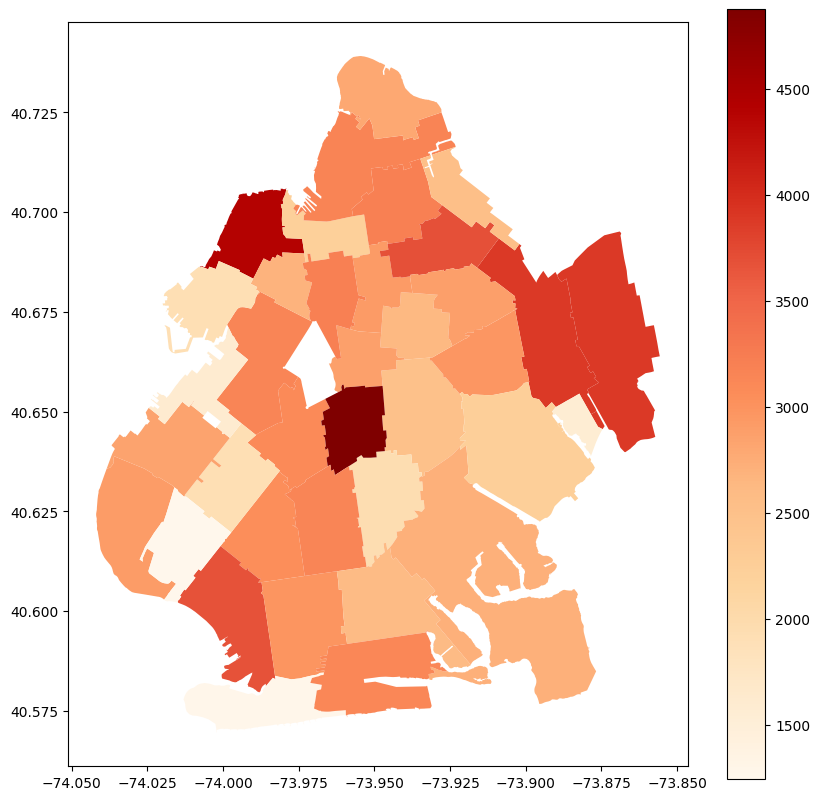

In [66]:
import matplotlib.pyplot as plt

# Plot gdf_merged as a choropleth shaded by complaint_count.
gdf_merged.plot(column='complaint_count', cmap='OrRd', legend=True, figsize=(10,10))
# Add a title with plt.title().
# Call plt.show() at the end.
plt.show()


## Day 5 Recap

| What you did | Why it matters |
|---|---|
| `gpd.read_file()` | Loads any spatial file — GeoJSON, shapefile, etc. |
| Checked dtypes before merging | Type mismatch is the #1 silent merge failure |
| Merged a GeoDataFrame | Same pattern as Day 4, result keeps the geometry |
| Choropleth | Turns a table into a spatial story |

### What's coming on Day 6

We'll add B38 bus stop locations on top of this map — your first multi-layer map.
You'll see whether high-complaint zip codes are also low-transit-access areas.